# <span style="color: purple;">Lesson 5 - Training vs Testing</span>

**Developers:** Brian  |  **Reviewers:** 

---

## <span style="color: purple;">🎯 Learning Objectives</span>

In this lesson, you will teach a computer how to read handwritten numbers (0-9) using a high-resolution dataset of 10,000 images. However, the real goal is to spot how models can accidentally cheat during training. 

By the end of this lesson, you will have:

- **Trained a model on all available data** and seen firsthand how it can fake a perfect score by memorising the dataset
- **Split the dataset** into separate training and testing sets to block the model from cheating
- **Compared model performances** to understand exactly why testing a model on new, unseen data is the most important rule in AI

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [32]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🏫 How do we know if a model has actually learned?</span>

Imagine a teacher giving a class a list of 100 math problems and their answers to study. The next day, the teacher gives them a test using the **exact same 100 problems**. 

If a student gets a perfect score, does it mean they are brilliant at math? Not necessarily! They might have just memorised the answers without actually understanding the rules of math.

This is a huge problem in machine learning. If we test a model on the same data it learned from, it can "cheat" by memorising the answers. 

<div class="alert alert-success">

**Generalisation** - A model's ability to make good predictions on new, unseen data, rather than just memorising the training data.

</div>

---

## <span style="color: purple;">Step 1 - Look at the data</span>

We will use a famous dataset of high-resolution handwritten digits (numbers 0 to 9), represented by their 28x28 pixel values. We will load an extracted subset of 10,000 images, and we want the model to correctly identify which digit is written.

<div class="alert alert-info">

**Run the code below** to load the dataset and view an example of every single digit in the dataset.

</div>

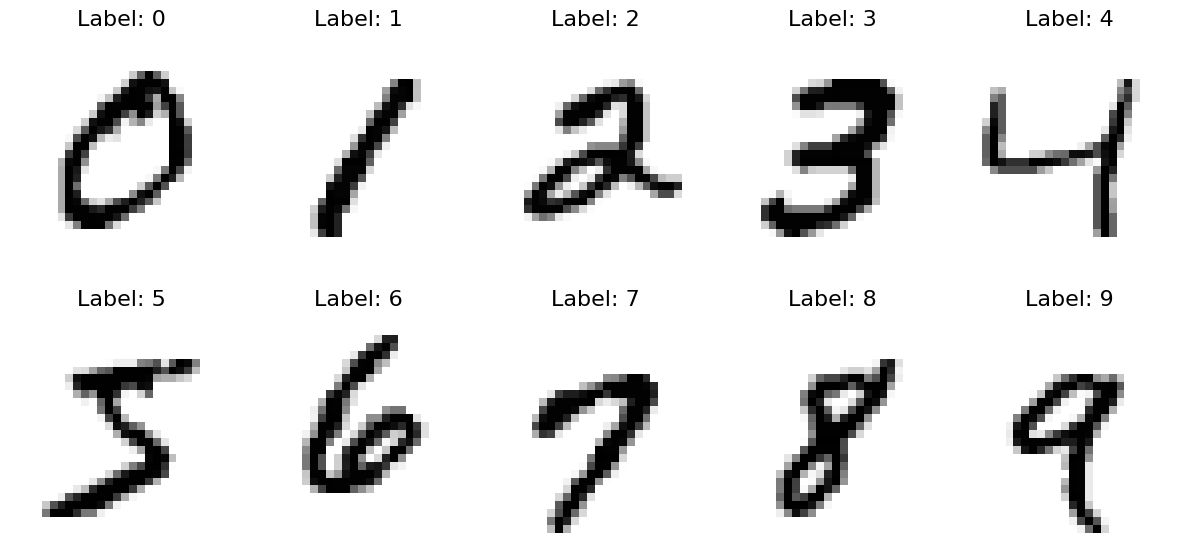

✓ Data loaded and images shown


In [35]:
# Load the dataset of high-resolution handwritten digits (MNIST)
# This downloads from the internet and may take a few seconds!
print("Downloading high-res dataset... this may take a few seconds.")
mnist_data = fetch_openml('mnist_784', version=1, parser='auto', data_home='.')

# To keep the lesson moving fast, we'll only use the first 10,000 images
X = mnist_data.data.to_numpy()[:5000]
y = mnist_data.target.to_numpy()[:5000]

# Display one example of each digit (0 to 9)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(10):
    # Find the very first image for digit 'i'
    # Important: OpenML targets are strings ('0', '1', etc)
    idx = np.where(y == str(i))[0][0]
    
    # High resolution images are 28x28 pixels
    img = X[idx].reshape(28, 28)
    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(f"Label: {y[idx]}", fontsize=16, pad=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

print("✓ Data loaded and images shown")

---

## <span style="color: purple;">Step 2 - Marking our own homework</span>

Let's see what happens when we train a model and test it on the **exact same data**.

<div class="alert alert-info">

**Run the code below** to train a model on all 10,000 images, and then test the model on those exact same 10,000 images.

</div>

In [36]:
# Create and train the model on ALL the data
cheat_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42)
cheat_model.fit(X, y)

# Test the model on the SAME data it just learned from
predictions = cheat_model.predict(X)
accuracy = accuracy_score(y, predictions)

print(f"Accuracy when testing on the training data: {accuracy * 100:.1f}%")
print("✓ Step 2 complete")

Accuracy when testing on the training data: 100.0%
✓ Step 2 complete


<div class="alert alert-info">

### 🧐 100% Accuracy?

Wow, a perfect score! But remember our math student. Because the model was tested on the exact same images it learned from, it just memorised all 10,000 answers. We have absolutely no idea if it can identify a *newly drawn* number correctly.

This is why we need proper **model evaluation**.

</div>

<div class="alert alert-success">

**Model evaluation** - The process of testing a model to see how well it performs, using data it hasn't seen before.

</div>

---

## <span style="color: purple;">Step 3 - Splitting the data</span>

To properly test our model, we must hide some data during training.

<div class="alert alert-success">

**Data splitting** - Dividing our dataset into a "training set" (for the model to learn from) and a "testing set" (kept completely hidden to test the model later).

</div>

<div class="alert alert-info">

**Run the code below** to split our dataset.

</div>

In [37]:
# Split the data - keep 80% for training, hide 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Images for training: {len(X_train)}")
print(f"Images for testing:  {len(X_test)}")
print("✓ Step 3 complete")

Images for training: 4000
Images for testing:  1000
✓ Step 3 complete


We now have 8,000 images for the model to learn from, and 2,000 completely separate images set aside for testing.

---

## <span style="color: purple;">Step 4 - The real test</span>

Now let's train a completely new model using ONLY the training images, and evaluate it using the testing images.

<div class="alert alert-info">

**Run the code below** to see how the model performs on data it hasn't seen yet.

</div>

In [38]:
# Create and train a new model, using ONLY the training data
honest_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42)
honest_model.fit(X_train, y_train)

# Test the model on the hidden testing data
honest_predictions = honest_model.predict(X_test)
honest_accuracy = accuracy_score(y_test, honest_predictions)

print(f"Accuracy on NEW, unseen data: {honest_accuracy * 100:.1f}%")
print("✓ Step 4 complete")

Accuracy on NEW, unseen data: 86.2%
✓ Step 4 complete


<div class="alert alert-info">

### 📉 A lower score, but a more honest one

The accuracy plummeted drastically from 100% to around 95%. Making predictions on completely new handwriting is obviously much harder than memorising old data! However, we now have a truthful and realistic evaluation of how well our AI actually works.

</div>

---

## <span style="color: purple;">Step 5 - Learning from mistakes</span>

Since the honest model got about 80.5% accuracy, it means it got some images wrong! Let's display a few of the testing images that the model completely misclassified.

<div class="alert alert-info">

**Run the code below** to view the model's mistaken predictions.

</div>

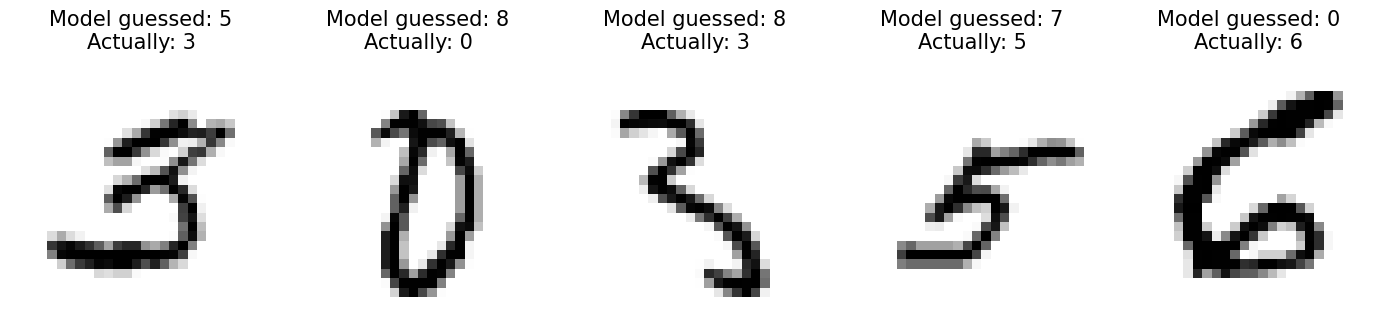

✓ Mistakes shown


In [39]:
# Find the indexes where the model's guess didn't match the actual answer
mistakes = np.where(honest_predictions != y_test)[0]

# Show the first 5 mistakes
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, ax in enumerate(axes):
    if i < len(mistakes):
        idx = mistakes[i]
        # Reshape the 1D test data back into a 28x28 image
        img = X_test[idx].reshape(28, 28)
        axes[i].imshow(img, cmap='gray_r')
        axes[i].set_title(f"Model guessed: {honest_predictions[idx]}\nActually: {y_test[idx]}", fontsize=15, pad=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

print("✓ Mistakes shown")

<div class="alert alert-info">

### ❓ Why is the model not perfect?

As you can see, some of these handwritten numbers are quite messy and difficult to read, even for a human! When the model encounters data like these, it might not be able to recognuse them. Testing the model on unseen data helps us identify its weaknesses and figure out how to improve it.

### 📈 How to improve the model's performance?

We can improve via two main avenues:

1. **Data**:
    1. More data - the model can learn from more examples, same as doing more practice questions for a exam
    1. Better quality data - the model can learn from higher quality examples e.g. better quality images, same as doing practice questions that better reflect principles tested in a exam
    
2. **Model**:
    1. Optimise model - the model is tuned to learn more efficiently, same as using revision guides rather than just reading the text book 
    1. More complex model -  the model has a greater learning capacity, same as asking a year 11 student to sit GCSEs rather than a year 9 student 

</div>

---

## <span style="color: purple;">🧠 What did we just do?</span>

We discovered why taking shortcuts in model evaluation is extremely dangerous. 

When we tested a model on the same data it was trained on, it achieved a deceptive 100% accuracy. By **splitting the data** into separate training and testing sets, we forced the model to prove it had actually learned (generalised) rather than just memorised the answers.

Checking a model on completely unseen data is the most important rule in machine learning!

---

### Key words

| Word | What it means |
|------|--------------|
| **Generalisation** | A model's ability to make good predictions on new, unseen data |
| **Model evaluation** | Testing a model to see how well it performs |
| **Data splitting** | Dividing a dataset into a training set and a testing set |

---

## <span style="color: purple;">🔧 Your turn!</span>

What happens if we hide *too much* data for testing, leaving the model with very little data to playfully learn from? 

**Change `test_amount` below from 0.2 (20%) to 0.95 (95%), then re-run. What happens to the accuracy?**

In [ ]:
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼  CHANGE THIS  ▼▼▼▼▼▼▼▼▼▼▼▼▼▼
test_amount = 0.2   # ← try 0.95
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲  CHANGE THIS  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=test_amount, random_state=42)

new_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42)
new_model.fit(X_train_new, y_train_new)

print(f"Images for training: {len(X_train_new)}")
print(f"Accuracy on unseen data: {accuracy_score(y_test_new, new_model.predict(X_test_new)) * 100:.1f}%")

---

## <span style="color: purple;">🧪 Quick Quiz</span>

Test yourself on what you just learned. Run the code cell, select your answer for each question, then click **Check answers**.

In [ ]:
from quiz import run_b05_quiz
run_b05_quiz()